In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import structural_similarity as ssim

In [2]:
# Extracts game boxes from storage to be used for comparison
def extract_game_boxes(image_path) -> list:
    """
    Steps:
    1. Read image from storage
    2. Convert to grayscale
    3. Apply adaptive thresholding to get binary image
    4. Dilate the image to connect components
    5. Find contours in the dilated image
    6. Filter contours based on width and height to identify game boxes
    7. Crop and store the identified game boxes
    """
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51,
        5
    )

    kernel = np.ones((7, 7), np.uint8)
    dilated = cv2.dilate(thresh, kernel, 2)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    game_boxes = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w < 500 or h < 700:
            continue

        game_boxes.append((x, y, w, h))

    cropped_boxes = []
    for (x, y, w, h) in game_boxes:
        cropped_boxes.append(img[y:y+h, x:x+w])

    return cropped_boxes

In [3]:
# Cleans up an image to then be used for comparison

def clean_input_image(img):
    """
    Steps:
    1. Load image from disk
    2. Resize to a standard width (keeps aspect) so matching is more predictable
    3. Convert to grayscale
    4. Denoise slightly (phone images can be grainy)
    5. Improve contrast
    6. Get a clean binary/edge representation using auto-derived values
    7. Return all important intermediates
    """
    # 1. load
    target_width = 800
    h, w = img.shape[:2]
    if w > target_width:
        scale = target_width / w
        img = cv2.resize(img, (target_width, int(h * scale)), interpolation=cv2.INTER_AREA)

    # 3. grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    smooth = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # 5. contrast improvement (helps when input is dull / badly lit)
    #    CLAHE derives parameters from local tiles, so less magic-numbery
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(smooth)

    # 6A. automatic threshold (Otsu) – good for near-bimodal images
    #     you can use this for template-ish matching later
    _, th_otsu = cv2.threshold(
        enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 6B. auto Canny edges – thresholds derived from median of the image
    #     good when you want shape/box edges for “game” detection
    v = np.median(enhanced)
    lower = int(max(0, 0.66 * v))
    upper = int(min(255, 1.33 * v))
    edges = cv2.Canny(enhanced, lower, upper)

    # 7. (optional) small morphological close to join broken edges
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    edges_clean = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

    results = {
        "original": img,
        "gray": gray,
        "smooth": smooth,
        "enhanced": enhanced,
        "binary": th_otsu,
        "edges": edges_clean
    }
    return results

In [ ]:
def compare_images(input_image, storage_image):
    """
    Steps:
    1. Use ORB to detect and compute keypoints and descriptors for both images
    2. Match features using BFMatcher with Hamming distance
    3. Compute a similarity score based on the matches
    4. Return whether images are similar based on the score
    """
    orb = cv2.ORB_create()
    _, des1 = orb.detectAndCompute(input_image, None)
    _, des2 = orb.detectAndCompute(storage_image, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    score = sum([1/m.distance for m in matches])
    if score > 3:
        print("Images are similar")
        return True
    else:
        print("Images are different")
        return False

ORB similarity score: 1.7939300677196834
Images are different
ORB similarity score: 1.7963523589762591
Images are different
ORB similarity score: 2.1826124706990258
Images are different
ORB similarity score: 3.4979103179914066
Images are similar
Match Found!


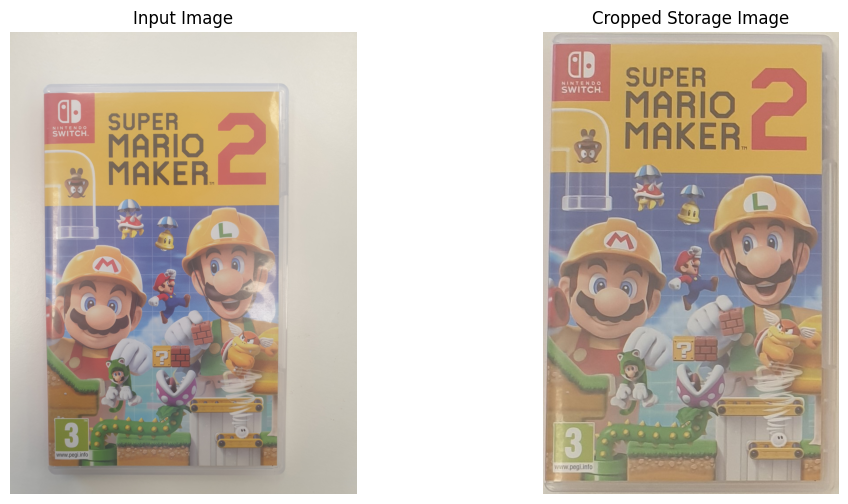

In [21]:
# Main Program Flow

# Input Game Image Path
input_image = cv2.imread("./InputImages/super.jpg")

cleaned_input_image = clean_input_image(input_image)

# Storage Image Path
storage_images = extract_game_boxes("./StorageImages/storage_3.jpg")
cleaned_storage_images = []
for image in storage_images:
    cleaned_storage_images.append(clean_input_image(image))


for cleaned_storage_image in cleaned_storage_images:
    if compare_images(cleaned_input_image["edges"], cleaned_storage_image["edges"]):
        print("Match Found!")
        input_image_rgb = cv2.cvtColor(cleaned_input_image["original"], cv2.COLOR_BGR2RGB)
        storage_image_rgb = cv2.cvtColor(cleaned_storage_image["original"], cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12,6))
        plt.subplot(1,2,1)
        plt.imshow(input_image_rgb)
        plt.title("Input Image")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(storage_image_rgb)
        plt.title("Cropped Storage Image")
        plt.axis("off")
        plt.show()
        break